# Lab 9 — World Model + Policy (Tiny Dreamer)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab09_world_model_policy/notebook_en.ipynb)

**World Models & Spatial Intelligence · Hands-on Lab 9 · the closed-loop experiment of the Scientist track**

In Labs 0–2 we built a world (hand-written transitions) and learned latent dynamics (transitions learned from data). This lab adds the last piece of the puzzle: **the policy**. We build a complete Tiny Dreamer-style closed loop:

$$\text{Observation} \rightarrow \text{World Model} \rightarrow \text{Imagined Rollouts} \rightarrow \text{Actor + Critic} \rightarrow \text{Action}$$

There is only one core question: **can a policy be trained mostly in "imagination", saving interaction samples from the real environment?** We run two experiments with the same actor-critic structure, one trained directly in the real environment (the model-free baseline) and one trained mostly inside a learned world model (Dreamer-style), and compare their sample efficiency with **real environment steps** on the x axis. Finally, we deliberately reproduce **model bias**: the policy "games the model" in imagination, with high imagined returns that the real environment does not pay out. This sets up Lab 10.

> Note: this is not a full DreamerV3 reproduction (no RSSM, KL balancing, symlog or λ-return), but a minimal experiment that keeps its core idea: **learn the model, learn the policy in imagination**. Every experiment finishes on CPU within a few minutes.

## 1. Motivation: why train a policy in "imagination"?

In model-free RL (such as REINFORCE and PPO), every learning signal comes from interaction with the real environment. In simulation that only costs electricity, but in the real world (robots, autonomous driving, experimental science) every interaction has a cost: mechanical wear, time, safety risk.

A world model changes the accounting: if the model is accurate enough, the policy's gradient signal can come mostly from **imagined trajectories**, produced by "dreaming" inside the model. An imagined step costs no real sample, and you can roll out as many as you like. This is the core idea of the Dreamer family (DreamerV1/V2/V3), and a modern version of the Dyna idea (Sutton, 1991):

- **World Model Learning**: train $p(s_{t+1}, r_t \mid s_t, a_t)$ on real data;
- **Actor-Critic in Imagination**: start from real states in the replay buffer, roll out H steps in the model, and train the actor and critic on imagined rewards;
- **Real Environment**: the actor goes back to the real environment for a small number of steps; new data enters the buffer, and the model is updated again.

With the three loops turning, real samples are only spent on "calibrating the model", not on "learning a policy directly by trial and error". In this lab we implement all three loops and measure how many samples they actually save.

## 2. Setup

**Why:** the only heavy dependency is PyTorch (the CPU build is fine, and Colab has it preinstalled); `imageio` saves the policy GIF. The cell below behaves the same on Colab and in local Jupyter: it installs whatever is missing.

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg, name in [("torch", "torch"), ("imageio", "imageio")]:
    ensure(pkg, name)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import torch
import torch.nn as nn
from torch.distributions import Categorical

%matplotlib inline
os.makedirs("assets", exist_ok=True)

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

T0 = time.time()
def elapsed():
    return f"[{time.time() - T0:6.1f}s]"

print("torch", torch.__version__, "| numpy", np.__version__)

torch 2.14.0+cu130 | numpy 2.4.6


## 3. Environment: Goal-Reaching Ball World

**Why not image observations:** Lab 2 already did image-based latent dynamics (ConvEncoder + decoder); that trains in minutes but would eat into this lab's compute budget. The teaching focus here is the **policy-in-imagination closed loop**, so we reduce the observation to a 6-D vector, `[x, y, vx, vy, gx, gy]` (with a little noise), and the world model becomes a small MLP that trains in seconds. The idea is exactly the same; the encoder is just the identity.

The environment turns Lab 0's `MovingBallWorld` into a **goal-reaching task** (the physics is fully reused: semi-implicit Euler, friction, wall bounce):

- **State / Observation** $s = (x, y, v_x, v_y, g_x, g_y) + \epsilon$: the ball's position and velocity and the goal position;
- **Action**: 9 discrete force directions $(a_x, a_y) \in \{-1, 0, 1\}^2$;
- **Reward**: $r_t = -\lVert p_t - g \rVert_2$ (dense shaping); reaching the goal (distance < 0.08) gives an extra +1 and ends the episode;
- **Episode**: at most 50 steps.

In [2]:
class GoalBallWorld:
    # 2D goal-reaching world: a ball in the unit square, pushed toward a goal point by forces (same physics as Lab 0)
    ACTION_TABLE = [(ax, ay) for ax in (-1, 0, 1) for ay in (-1, 0, 1)]  # 9 actions

    def __init__(self, dt=0.1, friction=0.95, bounce=0.8, force_scale=2.0,
                 goal_thresh=0.08, max_steps=50, obs_noise=0.005, seed=None):
        self.dt = dt                  # integration step
        self.friction = friction      # per-step velocity decay
        self.bounce = bounce          # fraction of velocity kept after a wall hit
        self.force_scale = force_scale
        self.goal_thresh = goal_thresh   # how close counts as "reached"
        self.max_steps = max_steps
        self.obs_noise = obs_noise    # observation noise std
        self.rng = np.random.default_rng(seed)
        self.state = None             # (x, y, vx, vy)
        self.goal = None              # (gx, gy)
        self.steps = 0

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        self.state = np.array([*self.rng.uniform(0.1, 0.9, size=2), 0.0, 0.0])
        while True:  # make sure the initial distance isn't too small, so the task is meaningful
            self.goal = self.rng.uniform(0.1, 0.9, size=2)
            if np.linalg.norm(self.goal - self.state[:2]) > 0.3:
                break
        self.steps = 0
        return self.observe()

    def step(self, action):
        ax, ay = self.ACTION_TABLE[action] if np.isscalar(action) else action
        x, y, vx, vy = self.state
        # semi-implicit Euler: update velocity first (force + friction), then position
        vx = (vx + self.force_scale * ax * self.dt) * self.friction
        vy = (vy + self.force_scale * ay * self.dt) * self.friction
        x = x + vx * self.dt
        y = y + vy * self.dt
        # inelastic wall bounce
        if x < 0: x, vx = -x, -vx * self.bounce
        if x > 1: x, vx = 2 - x, -vx * self.bounce
        if y < 0: y, vy = -y, -vy * self.bounce
        if y > 1: y, vy = 2 - y, -vy * self.bounce
        self.state = np.array([x, y, vx, vy])
        self.steps += 1
        dist = float(np.linalg.norm(self.state[:2] - self.goal))
        reward = -dist
        done = dist < self.goal_thresh
        if done:
            reward += 1.0  # arrival bonus
        trunc = self.steps >= self.max_steps
        return self.observe(), reward, done or trunc, {
            "state": self.state.copy(), "dist": dist, "success": done}

    def observe(self):
        # low-dimensional observation: full state + goal, with a little noise
        obs = np.concatenate([self.state, self.goal])
        return obs + self.rng.normal(0.0, self.obs_noise, size=6)

    def render(self, size=64):
        # 64x64 RGB: white ball + red goal (Lab 0 style, for visualization/GIFs)
        img = np.zeros((size, size, 3), dtype=np.uint8)
        yy, xx = np.mgrid[0:size, 0:size]
        px = int(np.clip(self.state[0], 0, 1) * (size - 1))
        py = int(np.clip(self.state[1], 0, 1) * (size - 1))
        img[(xx - px) ** 2 + (yy - py) ** 2 <= 3 ** 2] = [255, 255, 255]
        gx = int(self.goal[0] * (size - 1))
        gy = int(self.goal[1] * (size - 1))
        img[max(gy - 1, 0):gy + 2, max(gx - 1, 0):gx + 2] = [255, 0, 0]
        return img

print("GoalBallWorld defined. Actions:", GoalBallWorld.ACTION_TABLE)

GoalBallWorld defined. Actions: [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 0), (0, 1), (1, -1), (1, 0), (1, 1)]


**Why smoke-test first:** as in Lab 0, before trusting any training curve, verify the environment's invariants: the observation shape, the sign of the reward, the random policy's baseline return. Every "sample efficiency" number later only means something when compared against this random baseline.

observation: [ 0.72   0.45  -0.    -0.004  0.18   0.884]  shape: (6,)
t=0  reward=-0.6929  done=False  dist=0.693
t=1  reward=-0.6929  done=False  dist=0.693
t=2  reward=-0.6929  done=False  dist=0.693

random policy: mean return = -25.89  (n=20 episodes)


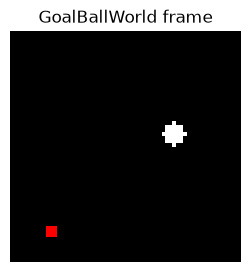

In [3]:
env = GoalBallWorld(seed=0)
obs = env.reset(seed=42)
print("observation:", np.round(obs, 3), " shape:", obs.shape)
for t in range(3):
    obs, reward, done, info = env.step(4)  # action 4 = (0, 0), no force
    print(f"t={t}  reward={reward:+.4f}  done={done}  dist={info['dist']:.3f}")

# random-policy baseline: every later curve should clearly beat it (uses the same eval seeds as evaluate)
rng = np.random.default_rng(0)
rand_rets = []
for ep in range(20):
    e = GoalBallWorld(seed=100)
    e.reset(seed=1000 + ep)
    tot = 0.0
    for t in range(50):
        _, r, d, _ = e.step(int(rng.integers(0, 9)))
        tot += r
        if d:
            break
    rand_rets.append(tot)
RANDOM_RETURN = float(np.mean(rand_rets))
print(f"\nrandom policy: mean return = {RANDOM_RETURN:.2f}  (n=20 episodes)")

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(env.render())
ax.set_title("GoalBallWorld frame")
ax.axis("off")
plt.show()

## 4. Build the Model: World Model + Actor-Critic

**Two networks, three roles:**

- **World Model** $f_\theta$: takes $(s_t, a_t)$ (the action one-hot encoded) and predicts the increment $\Delta s$ of the next observation and the reward $\hat r$. Predicting the increment (residual) is easier than predicting $s_{t+1}$ directly, because the identity map is a free prior. It is the low-dimensional version of `dyn(z, a)` from Lab 2, plus a **reward head**.
- **Actor** $\pi_\phi(a \mid s)$: a softmax over the 9 discrete actions.
- **Critic** $V_\psi(s)$: a scalar baseline that reduces the variance of the policy gradient.

The actor and critic are deliberately **separate small MLPs** (no shared trunk), so the model-free and Dreamer experiments later can use **exactly the same structure and hyperparameters**, with the only variable being "do the trajectories come from the real environment or from the model".

In [4]:
OBS_DIM, N_ACTIONS = 6, 9

class WorldModel(nn.Module):
    # (s_t, a_t) -> (s_{t+1}, r_t): MLP dynamics + reward head
    def __init__(self, obs_dim=OBS_DIM, n_actions=N_ACTIONS, hidden=128):
        super().__init__()
        self.n_actions = n_actions
        self.trunk = nn.Sequential(
            nn.Linear(obs_dim + n_actions, hidden), nn.ELU(),
            nn.Linear(hidden, hidden), nn.ELU())
        self.delta_head = nn.Linear(hidden, obs_dim)   # predict the increment Δs
        self.reward_head = nn.Linear(hidden, 1)        # predict the reward

    def forward(self, s, a_idx):
        a_onehot = nn.functional.one_hot(a_idx, self.n_actions).float()
        h = self.trunk(torch.cat([s, a_onehot], dim=-1))
        return s + self.delta_head(h), self.reward_head(h).squeeze(-1)

class ActorCritic(nn.Module):
    # actor: softmax policy over 9 actions; critic: scalar value baseline
    def __init__(self, obs_dim=OBS_DIM, n_actions=N_ACTIONS, hidden=64):
        super().__init__()
        self.actor = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, n_actions))
        self.critic = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1))

GAMMA = 0.99      # discount factor
ENT_COEF = 0.01   # entropy bonus, keeps the policy from collapsing too early
print(f"world model params: {sum(p.numel() for p in WorldModel().parameters()):,}")
print(f"actor-critic params: {sum(p.numel() for p in ActorCritic().parameters()):,}")

world model params: 19,463
actor-critic params: 9,866


## 5. Train

### 5.1 Collect seed data + train the World Model

**Why collect seed data with a random policy:** when the loop starts there is no policy yet, and uniform random is the simplest data-collection strategy (the original Dreamer paper does the same). Here we spend **2500 steps of real interaction**, the bulk of the Dreamer group's real-sample budget; the cost afterwards is small.

The world model's loss is plain supervised learning: $\mathcal{L} = \lVert \hat{s}_{t+1} - s_{t+1} \rVert^2 + 5 \cdot (\hat r_t - r_t)^2$. The reward gets 5× weight because it is crucial for the downstream policy, and its numeric scale is smaller than the state error.

In [5]:
def collect_random(env, n_steps):
    # collect transitions with a random policy: the world model's training set
    buf = {"s": [], "a": [], "r": [], "s2": []}
    obs = env.reset()
    for _ in range(n_steps):
        a = int(env.rng.integers(0, N_ACTIONS))
        o2, r, d, _ = env.step(a)
        buf["s"].append(obs); buf["a"].append(a)
        buf["r"].append(r);   buf["s2"].append(o2)
        obs = o2
        if d:
            obs = env.reset()
    return {k: np.array(v, dtype=np.float32) for k, v in buf.items()}

def train_world_model(wm, buf, epochs=200, bs=512, lr=1e-3, opt=None, verbose=False):
    s  = torch.from_numpy(buf["s"])
    a  = torch.from_numpy(buf["a"]).long()
    r  = torch.from_numpy(buf["r"])
    s2 = torch.from_numpy(buf["s2"])
    if opt is None:
        opt = torch.optim.Adam(wm.parameters(), lr=lr)
    n = len(s)
    for ep in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            s2_hat, r_hat = wm(s[idx], a[idx])
            loss = ((s2_hat - s2[idx]) ** 2).mean() + 5.0 * ((r_hat - r[idx]) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        if verbose and (ep + 1) % 50 == 0:
            print(f"  epoch {ep + 1}: loss = {loss.item():.6f}")
    return opt

SEED_STEPS = 2500   # real environment steps: the Dreamer group's "seed data" budget
env_d = GoalBallWorld(seed=10)
buffer = collect_random(env_d, SEED_STEPS)
print(elapsed(), f"seed data: {len(buffer['s'])} real steps, mean reward = {buffer['r'].mean():.3f}")

wm = WorldModel()
wm_opt = train_world_model(wm, buffer, epochs=200, verbose=True)
wm.eval()
print(elapsed(), "world model trained")

[   0.1s] seed data: 2500 real steps, mean reward = -0.483


  epoch 50: loss = 0.180618


  epoch 100: loss = 0.124147


  epoch 150: loss = 0.038429


  epoch 200: loss = 0.027346
[   3.2s] world model trained


### 5.2 Actor-Critic in Imagination (the core algorithm)

This is the most important code cell in the lab and worth reading line by line. One imagination update:

$$s_0 \sim \text{replay buffer}, \qquad a_t \sim \pi_\phi(\cdot \mid s_t), \qquad s_{t+1}, r_t \leftarrow f_\theta(s_t, a_t) \quad (\text{detach!})$$

Roll out $H = 15$ steps in imagination, then update with **REINFORCE + a learned value baseline**:

- **Return**: $G_t = \sum_{k \geq t} \gamma^{k-t} r_k + \gamma^{H-t} V_\psi(s_H)$ (bootstrap with the critic at the end of the imagination horizon; otherwise all return beyond 15 steps is lost);
- **Advantage**: $A_t = G_t - V_\psi(s_t)^{\text{detach}}$;
- **Actor loss**: $-\mathbb{E}[\log \pi(a_t \mid s_t) \cdot A_t] - \beta \, H(\pi)$ (entropy bonus);
- **Critic loss**: $\lVert V_\psi(s_t) - G_t \rVert^2$.

**Note where `torch.no_grad()` sits**: the world model's parameters are frozen in this phase and gradients do not pass through the model. This is a simplification: Dreamer actually backpropagates gradients analytically through the dynamics (analytic gradients); we use REINFORCE instead (see the Advanced Extension).

In [6]:
def imagination_update(wm, ac, starts, opt, H=15):
    # start from real states in the replay buffer, dream H steps in the world model, update the actor-critic
    s = starts.clone()
    logps, vals, rews, ents = [], [], [], []
    for t in range(H):
        logits = ac.actor(s)
        dist = Categorical(logits=logits)
        a = dist.sample()
        v = ac.critic(s).squeeze(-1)
        with torch.no_grad():          # model parameters frozen: no gradients through imagined steps
            s, r = wm(s, a)
        logps.append(dist.log_prob(a)); vals.append(v)
        rews.append(r);                 ents.append(dist.entropy())
    with torch.no_grad():
        G = ac.critic(s).squeeze(-1)   # bootstrap at the end of the horizon
    rets = []
    for t in reversed(range(H)):       # compute the discounted return backwards
        G = rews[t] + GAMMA * G
        rets.append(G)
    rets = torch.stack(rets[::-1])                       # (H, B)
    vals = torch.stack(vals); logps = torch.stack(logps); ents = torch.stack(ents)
    adv = rets - vals.detach()
    actor_loss = -(logps * adv).mean() - ENT_COEF * ents.mean()
    critic_loss = ((vals - rets) ** 2).mean()
    loss = actor_loss + 0.5 * critic_loss
    opt.zero_grad(); loss.backward(); opt.step()
    return loss.item()

def evaluate(env, ac, n_episodes=10):
    # greedy evaluation (real steps used for evaluation don't count toward the sample budget; standard practice)
    rets, succ = [], []
    for ep in range(n_episodes):
        obs = env.reset(seed=1000 + ep)   # fixed eval seeds for a fair comparison between the two experiments
        tot = 0.0; ok = False
        for t in range(env.max_steps):
            with torch.no_grad():
                a = int(ac.actor(torch.from_numpy(obs).float()).argmax())
            obs, r, done, info = env.step(a)
            tot += r
            if done:
                ok = info["success"]; break
        rets.append(tot); succ.append(ok)
    return float(np.mean(rets)), float(np.mean(succ))

print("imagination_update / evaluate defined")

imagination_update / evaluate defined


### 5.3 The Dreamer main loop: turning the three loops

Each iteration does three things, exactly the three loops from the Motivation:

1. **Actor-Critic in Imagination**: 50 imagination updates (batch 64 × horizon 15), **zero real samples**;
2. **Real Environment**: the current policy runs only **100 steps** in the real environment, and the data goes into the buffer;
3. **World Model Learning**: every 3 iterations, fine-tune the world model on the enlarged buffer.

Total real budget: 2500 (seed) + 25 × 100 = **5000 steps**. Watch how fast the eval return printed at each iteration rises.

In [7]:
ac = ActorCritic()
ac_opt = torch.optim.Adam(ac.parameters(), lr=3e-3)
s_all = torch.from_numpy(buffer["s"])

H_IMAG = 15           # imagination horizon
N_ITER = 25
UPDATES_PER_ITER = 50 # imagination updates per iteration (no real samples spent)
REAL_PER_ITER = 100   # only 100 steps of real data collected per iteration

real_steps = SEED_STEPS
dreamer_hist = [(real_steps, *evaluate(env_d, ac))]
print(elapsed(), f"iter  0: real_steps={real_steps}  return={dreamer_hist[0][1]:7.2f}  succ={dreamer_hist[0][2]:.2f}")

for it in range(1, N_ITER + 1):
    # --- loop 2: train the policy in imagination (zero real samples) ---
    wm.eval()
    for u in range(UPDATES_PER_ITER):
        idx = torch.randint(0, len(s_all), (64,))
        imagination_update(wm, ac, s_all[idx], ac_opt, H=H_IMAG)
    # --- loop 3: collect a little real-environment data ---
    new = {"s": [], "a": [], "r": [], "s2": []}
    obs = env_d.reset()
    for _ in range(REAL_PER_ITER):
        with torch.no_grad():
            a = int(Categorical(logits=ac.actor(torch.from_numpy(obs).float())).sample())
        o2, r, d, _ = env_d.step(a)
        new["s"].append(obs); new["a"].append(a); new["r"].append(r); new["s2"].append(o2)
        obs = o2
        if d:
            obs = env_d.reset()
    for k in buffer:
        buffer[k] = np.concatenate([buffer[k], np.array(new[k], dtype=np.float32)])
    real_steps += REAL_PER_ITER
    s_all = torch.from_numpy(buffer["s"])
    # --- loop 1: more data now, fine-tune the world model ---
    if it % 3 == 0:
        wm.train()
        wm_opt = train_world_model(wm, buffer, epochs=30, opt=wm_opt)
        wm.eval()
    ev = evaluate(env_d, ac)
    dreamer_hist.append((real_steps, *ev))
    print(elapsed(), f"iter {it:2d}: real_steps={real_steps}  return={ev[0]:7.2f}  succ={ev[1]:.2f}")

[   3.3s] iter  0: real_steps=2500  return= -28.28  succ=0.00


[   4.4s] iter  1: real_steps=2600  return= -17.29  succ=0.40


[   5.4s] iter  2: real_steps=2700  return= -14.12  succ=0.10


[   6.5s] iter  3: real_steps=2800  return=  -1.90  succ=1.00


[   7.2s] iter  4: real_steps=2900  return=  -1.49  succ=1.00


...

[  23.3s] iter 21: real_steps=4600  return=  -1.43  succ=1.00


[  24.1s] iter 22: real_steps=4700  return=  -1.36  succ=1.00


[  24.8s] iter 23: real_steps=4800  return=  -1.45  succ=1.00


[  26.2s] iter 24: real_steps=4900  return=  -1.43  succ=1.00


[  27.0s] iter 25: real_steps=5000  return=  -1.58  succ=1.00


### 5.4 Model-free baseline: the same agent, trained directly in the real environment

**The key to a controlled experiment is a "single variable"**: the same ActorCritic structure, the same lr, the same advantage estimate; the only difference is that all trajectories come from the real environment. One policy-gradient update per batch of 16 episodes; when an episode is truncated at max_steps we bootstrap with the critic (otherwise it would be equivalent to pretending "the world ends after 50 steps", which introduces bias).

We give it **10 times the Dreamer group's real-sample budget (50000 steps)** and see how much it needs to catch up.

In [8]:
def modelfree_update(env, ac, opt, n_episodes=16):
    # collect n_episodes full episodes in the real environment and do one batched policy-gradient update
    ep_s, ep_a, ep_r, ep_boot = [], [], [], []
    steps = 0
    for ep in range(n_episodes):
        obs = env.reset()
        S, A, R = [], [], []
        boot = 0.0
        for t in range(env.max_steps):
            st = torch.from_numpy(obs).float()
            with torch.no_grad():
                a = int(Categorical(logits=ac.actor(st)).sample())
            obs, r, done, info = env.step(a)
            S.append(st); A.append(a); R.append(r); steps += 1
            if done:
                if not info["success"]:   # truncated by timeout (not terminal): bootstrap the value
                    with torch.no_grad():
                        boot = float(ac.critic(torch.from_numpy(obs).float()))
                break
        ep_s.append(S); ep_a.append(A); ep_r.append(R); ep_boot.append(boot)
    logps, vals, rets, ents = [], [], [], []
    for S, A, R, boot in zip(ep_s, ep_a, ep_r, ep_boot):
        st = torch.stack(S); at = torch.tensor(A)
        dist = Categorical(logits=ac.actor(st))
        v = ac.critic(st).squeeze(-1)
        G = boot; rr = []
        for r in reversed(R):
            G = r + GAMMA * G; rr.append(G)
        logps.append(dist.log_prob(at)); vals.append(v)
        rets.append(torch.tensor(rr[::-1], dtype=torch.float32)); ents.append(dist.entropy())
    logps = torch.cat(logps); vals = torch.cat(vals)
    rets = torch.cat(rets);   ents = torch.cat(ents)
    adv = rets - vals.detach()
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)   # normalize the advantage to stabilize training
    loss = -(logps * adv).mean() - ENT_COEF * ents.mean() + 0.5 * ((vals - rets) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    return steps

env_m = GoalBallWorld(seed=20)
ac_mf = ActorCritic()
mf_opt = torch.optim.Adam(ac_mf.parameters(), lr=1e-3)

MF_BUDGET = 50000   # 10x the Dreamer group's real-sample budget
mf_steps = 0
mf_hist = [(0, *evaluate(env_m, ac_mf))]
while mf_steps < MF_BUDGET:
    mf_steps += modelfree_update(env_m, ac_mf, mf_opt, n_episodes=16)
    if mf_steps - mf_hist[-1][0] >= 2500:
        ev = evaluate(env_m, ac_mf)
        mf_hist.append((mf_steps, *ev))
        print(elapsed(), f"mf real_steps={mf_steps:6d}  return={ev[0]:7.2f}  succ={ev[1]:.2f}")
print(elapsed(), "model-free baseline done")

[  27.5s] mf real_steps=  2756  return= -21.08  succ=0.30


[  27.9s] mf real_steps=  5548  return= -20.28  succ=0.30


[  28.3s] mf real_steps=  8363  return= -19.96  succ=0.30


[  28.7s] mf real_steps= 11179  return= -20.57  succ=0.30


[  29.2s] mf real_steps= 14120  return= -19.68  succ=0.30


...

[  33.3s] mf real_steps= 39141  return= -14.53  succ=0.50


[  33.9s] mf real_steps= 41832  return=  -9.55  succ=0.80


[  34.4s] mf real_steps= 44631  return=  -9.43  succ=0.70


[  34.9s] mf real_steps= 47275  return= -11.88  succ=0.60


[  35.4s] mf real_steps= 50088  return= -10.78  succ=0.70
[  35.4s] model-free baseline done


## 6. Visualize: sample-efficiency comparison (the most important plot in this lab)

**The x axis is real environment steps, not training wall-clock.** This is the standard way model-based RL papers plot it, and the only fair comparison: millions of steps in imagination are "free", and what is truly expensive is every interaction with the real world. If the Dreamer curve reaches a high return at a much smaller x than model-free, the world model really has shifted the cost of learning from "real interaction" to "imagination + model fitting".

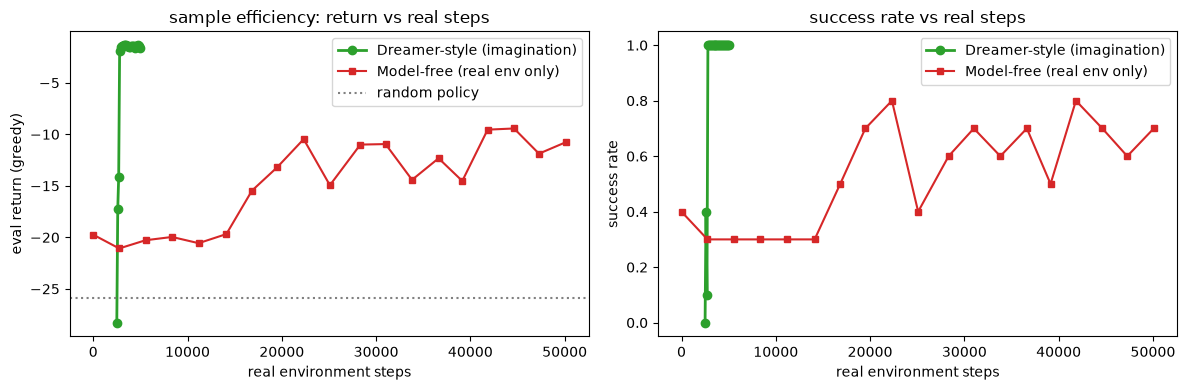

Dreamer-style: success>=0.9 at 2800 real steps, final return -1.58
Model-free   : success>=0.9 at None real steps (never within budget)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ds, dr, dc = zip(*dreamer_hist)
ms, mr, mc = zip(*mf_hist)
axes[0].plot(ds, dr, "o-", color="tab:green", lw=2, label="Dreamer-style (imagination)")
axes[0].plot(ms, mr, "s-", color="tab:red", ms=4, label="Model-free (real env only)")
axes[0].axhline(RANDOM_RETURN, color="gray", ls=":", label="random policy")
axes[0].set_xlabel("real environment steps"); axes[0].set_ylabel("eval return (greedy)")
axes[0].set_title("sample efficiency: return vs real steps"); axes[0].legend()
axes[1].plot(ds, dc, "o-", color="tab:green", lw=2, label="Dreamer-style (imagination)")
axes[1].plot(ms, mc, "s-", color="tab:red", ms=4, label="Model-free (real env only)")
axes[1].set_xlabel("real environment steps"); axes[1].set_ylabel("success rate")
axes[1].set_title("success rate vs real steps"); axes[1].legend()
plt.tight_layout()
plt.savefig("assets/reward_curves.png", dpi=120)
plt.show()

# quantitative comparison: real steps each needs to reach success >= 0.9
def steps_to_success(hist, thresh=0.9):
    for s, r, c in hist:
        if c >= thresh:
            return s
    return None
d_conv = steps_to_success(dreamer_hist)
m_conv = steps_to_success(mf_hist)
print(f"Dreamer-style: success>=0.9 at {d_conv} real steps, final return {dr[-1]:.2f}")
print(f"Model-free   : success>=0.9 at {m_conv} real steps" + (f" ({m_conv/d_conv:.0f}x more)" if m_conv and d_conv else " (never within budget)"))

### 6.1 Imagined rollout vs Real rollout

**Why look at this plot:** the Dreamer group's policy was trained inside the model, and it can transfer to the real environment only if imagined trajectories are close enough to real ones. Below, the trained policy starts from the same initial state twice: one trajectory walks in the real environment, the other feeds the same action sequence to the world model. The dashed line (imagination) should hug the solid line (reality) for the first few steps and then drift slowly, the same compounding-error phenomenon as in Lab 2. The bottom-right plot shows how the mean position error grows with the horizon.

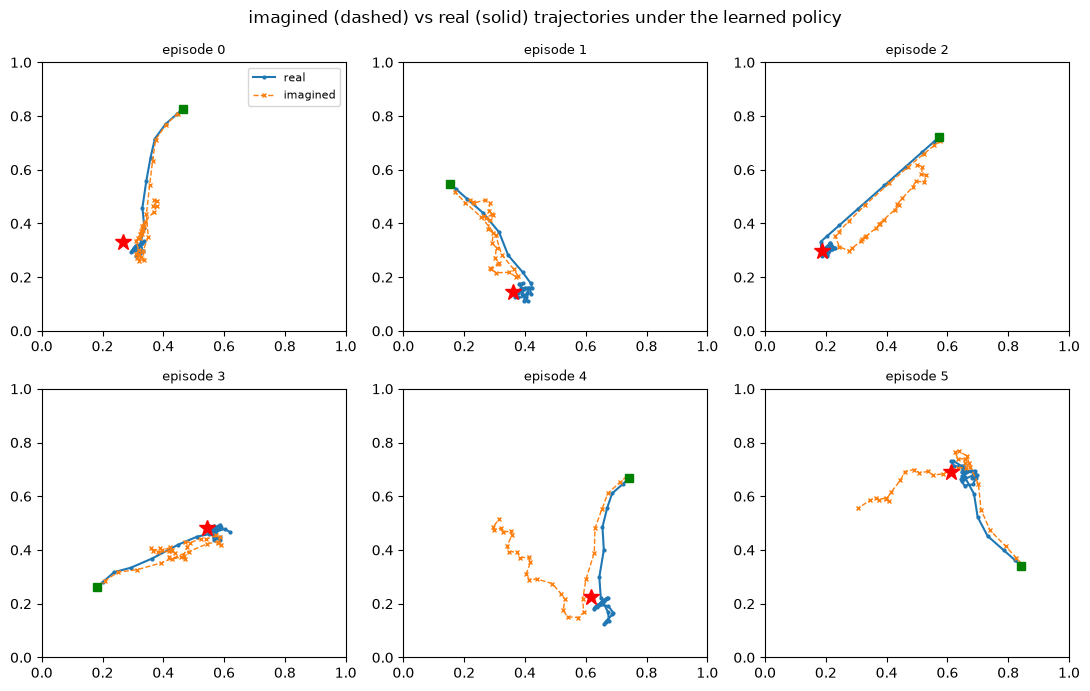

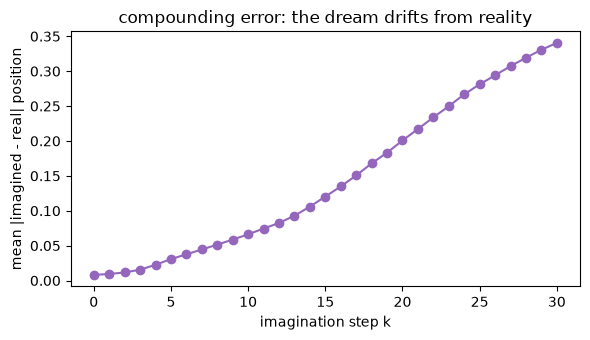

mean position error: step 1 = 0.0094, step 10 = 0.0662, step 20 = 0.2007


In [10]:
wm.eval()
HORIZON = 30
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
all_errs = []
for j in range(6):
    e = GoalBallWorld(seed=300)
    obs = e.reset(seed=4000 + j)
    obs0 = obs.copy()               # the imagined rollout starts from the same initial observation
    # real rollout (greedy policy), recording the action sequence
    # note: keep going for the full HORIZON steps after reaching the goal (ignore done) so long-horizon drift is visible
    real_xy = [e.state[:2].copy()]
    acts = []
    for t in range(HORIZON):
        with torch.no_grad():
            a = int(ac.actor(torch.from_numpy(obs).float()).argmax())
        acts.append(a)
        obs, r, d, _ = e.step(a)
        real_xy.append(e.state[:2].copy())
    # imagined rollout: same initial obs, same action sequence, world model only
    s = torch.from_numpy(obs0).float().unsqueeze(0)
    imag_xy = [obs0[:2].copy()]
    with torch.no_grad():
        for a in acts:
            s, r = wm(s, torch.tensor([a]))
            imag_xy.append(s[0, :2].numpy())
    real_xy = np.array(real_xy); imag_xy = np.array(imag_xy)
    err = np.linalg.norm(imag_xy - real_xy, axis=1)
    all_errs.append(err)
    ax = axes[j // 3, j % 3]
    ax.plot(real_xy[:, 0], real_xy[:, 1], "o-", color="tab:blue", ms=2, lw=1.5, label="real")
    ax.plot(imag_xy[:, 0], imag_xy[:, 1], "x--", color="tab:orange", ms=3, lw=1, label="imagined")
    ax.plot(*e.goal, "*", color="red", ms=12)
    ax.plot(*real_xy[0], "s", color="green", ms=6)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_title(f"episode {j}", fontsize=9)
    if j == 0:
        ax.legend(fontsize=8)
plt.suptitle("imagined (dashed) vs real (solid) trajectories under the learned policy")
plt.tight_layout()
plt.savefig("assets/imagined_vs_real.png", dpi=120)
plt.show()

errs = np.mean(np.array(all_errs), axis=0)
plt.figure(figsize=(6, 3.5))
plt.plot(errs, "o-", color="tab:purple")
plt.xlabel("imagination step k"); plt.ylabel("mean |imagined - real| position")
plt.title("compounding error: the dream drifts from reality")
plt.tight_layout(); plt.show()
print(f"mean position error: step 1 = {errs[1]:.4f}, step 10 = {errs[10]:.4f}, step 20 = {errs[20]:.4f}")

## 7. Evaluate: the final comparison + what the policy looks like

The three agents are evaluated on the same 20 fixed-seed episodes (greedy policy): the random policy, model-free (50k real steps), and Dreamer-style (5k real steps). Then look at the trajectories of the Dreamer group's learned policy: the ball should rush toward the goal in a roughly straight line.

agent                          real steps   return  success
------------------------------------------------------------
random                                  -   -25.89     0.30
model-free (real env)              50,000   -10.38     0.80
Dreamer-style (imagination)         5,000    -1.33     1.00


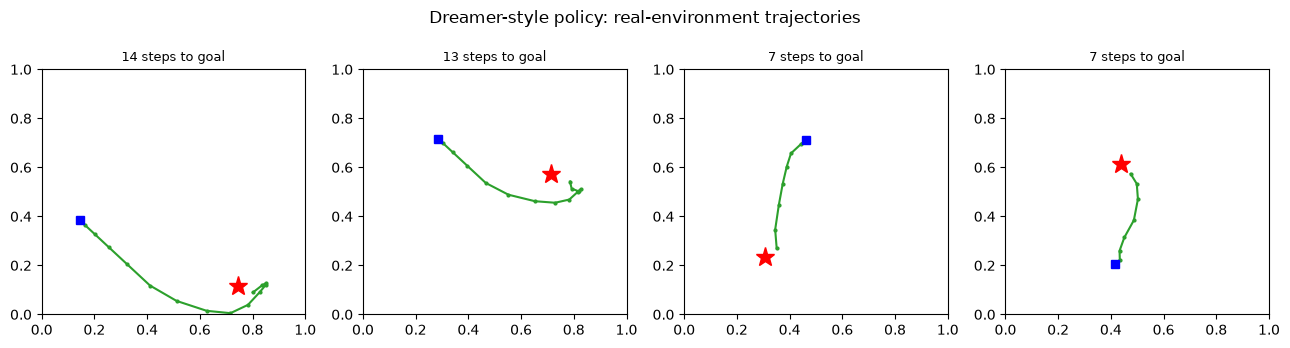

saved assets/learned_policy.gif


In [11]:
rows = []
# random (same rng/eval seeds as the Section 3 baseline)
rng = np.random.default_rng(0)
rets, succ = [], []
for ep in range(20):
    e = GoalBallWorld(seed=100); e.reset(seed=1000 + ep)
    tot = 0.0; ok = False
    for t in range(50):
        _, r, d, info = e.step(int(rng.integers(0, 9)))
        tot += r
        if d: ok = info["success"]; break
    rets.append(tot); succ.append(ok)
rows.append(("random", "-", np.mean(rets), np.mean(succ)))
rows.append(("model-free (real env)", "50,000", *evaluate(env_m, ac_mf, n_episodes=20)))
rows.append(("Dreamer-style (imagination)", f"{real_steps:,}", *evaluate(env_d, ac, n_episodes=20)))
print(f"{'agent':<30} {'real steps':>10} {'return':>8} {'success':>8}")
print("-" * 60)
for name, ns, r, c in rows:
    print(f"{name:<30} {ns:>10} {r:8.2f} {c:8.2f}")

# policy trajectory visualization + GIF
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
gif_frames = []
for j in range(4):
    e = GoalBallWorld(seed=300)
    obs = e.reset(seed=5000 + j)
    xy = [e.state[:2].copy()]
    for t in range(50):
        with torch.no_grad():
            a = int(ac.actor(torch.from_numpy(obs).float()).argmax())
        obs, r, d, _ = e.step(a)
        xy.append(e.state[:2].copy())
        if j == 0:
            gif_frames.append(e.render())
        if d:
            break
    xy = np.array(xy)
    axes[j].plot(xy[:, 0], xy[:, 1], "o-", ms=2, color="tab:green")
    axes[j].plot(*e.goal, "*", color="red", ms=14)
    axes[j].plot(*xy[0], "s", color="blue", ms=6)
    axes[j].set_xlim(0, 1); axes[j].set_ylim(0, 1)
    axes[j].set_title(f"{len(xy)-1} steps to goal", fontsize=9)
plt.suptitle("Dreamer-style policy: real-environment trajectories")
plt.tight_layout()
plt.savefig("assets/policy_trajectories.png", dpi=120)
plt.show()
imageio.mimsave("assets/learned_policy.gif", gif_frames, duration=0.1)
print("saved assets/learned_policy.gif")

## 8. Experiment: Model Bias — "gaming" the model in imagination

**The second core teaching point of this lab.** So far the story has been rosy, but world models have a toxic side: **the policy optimizer actively seeks out the directions where model error is largest**. The imagined return is inflated and the real environment does not pay out. This is **model bias / model exploitation**.

To reproduce it reliably in a small experiment, we switch the reward to **sparse** (+1 for reaching the goal, 0 otherwise), relabel the same buffer, and **weight the rare positive samples 50×** when training the reward head. A side effect of the weighting: the MLP smears the "+1 region" out larger than the real goal circle, so the model **systematically overestimates the reward** at some $(s, a)$. Then a fresh actor trains purely in imagination for 600 updates, and we track two quantities:

- **imagined return**: the policy's self-assessed return inside the model (how good the model says it is);
- **real return**: the true sparse return of the same policy in the real environment.

If model bias happens, the former keeps climbing while the latter stalls: the policy has learned to park in a fake region where "the model thinks there is reward".

positive samples: 277 / 5000  (rare positive samples!)


[  44.4s] update  60: imagined return= 22.38   real return= 0.10


[  45.3s] update 120: imagined return= 26.67   real return= 0.10


[  46.3s] update 180: imagined return= 40.52   real return= 0.90


[  47.1s] update 240: imagined return= 41.66   real return= 1.00


...

[  48.9s] update 360: imagined return= 43.12   real return= 1.00


[  49.9s] update 420: imagined return= 42.08   real return= 1.00


[  50.8s] update 480: imagined return= 43.10   real return= 1.00


[  51.7s] update 540: imagined return= 43.32   real return= 1.00


[  52.7s] update 600: imagined return= 42.58   real return= 1.00


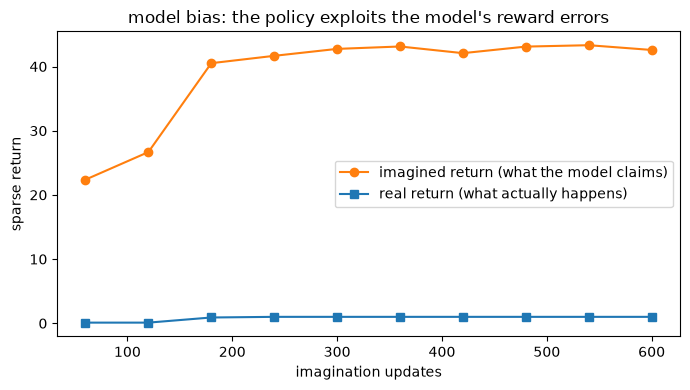

In [12]:
# same buffer, relabeled with a sparse reward: +1 for reaching the goal, 0 otherwise
dist = np.linalg.norm(buffer["s2"][:, :2] - buffer["s2"][:, 4:6], axis=1)
sparse_buf = {k: v.copy() for k, v in buffer.items()}
sparse_buf["r"] = (dist < env_d.goal_thresh).astype(np.float32)
print(f"positive samples: {int(sparse_buf['r'].sum())} / {len(sparse_buf['r'])}  (rare positive samples!)")

def train_wm_weighted(wm, buf, epochs=300, bs=512, lr=1e-3, pos_weight=50.0):
    # weight the positives so the reward head doesn't ignore rare successes; side effect: the "+1 region" gets smeared out
    s  = torch.from_numpy(buf["s"]); a = torch.from_numpy(buf["a"]).long()
    r  = torch.from_numpy(buf["r"]); s2 = torch.from_numpy(buf["s2"])
    w = 1.0 + pos_weight * (r > 0).float()
    opt = torch.optim.Adam(wm.parameters(), lr=lr)
    for ep in range(epochs):
        perm = torch.randperm(len(s))
        for i in range(0, len(s), bs):
            idx = perm[i:i + bs]
            s2_hat, r_hat = wm(s[idx], a[idx])
            loss = ((s2_hat - s2[idx]) ** 2).mean() + (w[idx] * (r_hat - r[idx]) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()

wm_sp = WorldModel()
train_wm_weighted(wm_sp, sparse_buf)
wm_sp.eval()

def imagined_return(wm, ac, starts, H=50):
    # the policy's self-assessment inside the model: the return the model claims
    s = starts.clone(); tot = torch.zeros(len(s))
    with torch.no_grad():
        for t in range(H):
            a = ac.actor(s).argmax(-1)
            s, r = wm(s, a)
            tot += r
    return tot.mean().item()

def real_sparse_return(env, ac, n=10):
    # the true sparse return of the same policy in the real environment
    rets = []
    for ep in range(n):
        obs = env.reset(seed=3000 + ep); tot = 0.0
        for t in range(env.max_steps):
            with torch.no_grad():
                a = int(ac.actor(torch.from_numpy(obs).float()).argmax())
            obs, r, d, info = env.step(a)
            tot += 1.0 if info["dist"] < env.goal_thresh else 0.0
            if d:
                break
        rets.append(tot)
    return float(np.mean(rets))

ac_sp = ActorCritic()
sp_opt = torch.optim.Adam(ac_sp.parameters(), lr=3e-3)
s_sp = torch.from_numpy(sparse_buf["s"])
bias_hist = []
for u in range(1, 601):
    idx = torch.randint(0, len(s_sp), (64,))
    imagination_update(wm_sp, ac_sp, s_sp[idx], sp_opt, H=H_IMAG)
    if u % 60 == 0:
        im = imagined_return(wm_sp, ac_sp, s_sp[:128])
        re = real_sparse_return(env_d, ac_sp)
        bias_hist.append((u, im, re))
        print(elapsed(), f"update {u:3d}: imagined return={im:6.2f}   real return={re:5.2f}")

us, ims, res = zip(*bias_hist)
plt.figure(figsize=(7, 4))
plt.plot(us, ims, "o-", color="tab:orange", label="imagined return (what the model claims)")
plt.plot(us, res, "s-", color="tab:blue", label="real return (what actually happens)")
plt.xlabel("imagination updates"); plt.ylabel("sparse return")
plt.title("model bias: the policy exploits the model's reward errors")
plt.legend(); plt.tight_layout()
plt.savefig("assets/model_bias.png", dpi=120)
plt.show()

**Reading the plot:** the imagined return climbs to 40+ (the policy believes it collects over 40 +1 rewards per 50 steps, i.e. a reward at almost every step), while the real return stays at ~1 (it really reaches the goal only once per 50 steps on average). The actor has found the fake high-reward region that the weighted reward head smeared out, and parks the ball there to "farm points". This is model bias in full: **the optimizer hill-climbs on the model's errors**.

Real Dreamer systems fight it with these tools (Lab 10 covers evaluation systematically):

- **Short-horizon imagination** (errors don't have time to compound: H=15, not 100);
- **Ensembles + an uncertainty penalty** (penalize when several models disagree, the PETS/MBPO idea);
- **λ-return / critic bootstrapping** (don't trust imagined rewards over the long run);
- **Continually recalibrating the model on real data** (the role of loops 1 and 3 in our three-loop cycle).

### ✏️ Exercise 1 — The effect of the imagination horizon

Change `H_IMAG` in the main loop (Section 5.3) to 5 and to 40 and rerun the Dreamer group. What happens when the horizon is too short / too long? (Hint: too short → the bootstrap term dominates and the policy is short-sighted; too long → compounding model error poisons the gradient. Just watch how the final return and the reward curve change.)

In [13]:
# YOUR CODE HERE
# hint: rerun the main loop of Section 5.3 (reinitialize ac / ac_opt / buffer) with H_IMAG set to 5 or 40
pass

### ✏️ Exercise 2 — The ratio of imagination to reality

`UPDATES_PER_ITER` and `REAL_PER_ITER` control the ratio of "imagined training / real collection". Try `(UPDATES_PER_ITER, REAL_PER_ITER) = (10, 100)` (too little imagination) and `(200, 50)` (too much imagination). Which ratio is the most sample-efficient? With too much imagination, do signs of model bias appear (imagined eval above real eval)?

In [14]:
# YOUR CODE HERE
pass

### ✏️ Exercise 3 — Strength of model bias vs amount of data

In the model-bias experiment of Section 8, change the seed data from 2500 steps to 800 (rerun `collect_random`) and leave everything else alone. Does the gap between imagined return and real return grow or shrink? Why? (Hint: the less data, the larger the region where the reward head extrapolates.)

In [15]:
# YOUR CODE HERE
pass

## 9. Questions

1. **The accounting of the x axis**: we treat rollouts in imagination as "free". In what sense is that true and in what sense not? If the task were training a real robot, what is the cost of imagination, and what is the cost of real interaction?
2. **Why is the model-free curve below the random baseline early on?** (Look at the first few thousand steps of the left plot in Section 6. What does policy gradient learn early, and why is the greedy eval actually worse?)
3. **Is the direction of model bias predictable?** In Section 8 we saw an "optimistic bias" (imagined > real). Are there cases of "pessimistic bias" (the model underestimates the policy's real return)? Which is more dangerous for closed-loop training?
4. If the observation were a 32×32 image (Lab 2's ConvEncoder), which components of this lab would have to change and which could stay as they are? Estimate how training time would change.

## 10. Takeaways

- **A world model is not just a prediction tool**: it shifts the cost of policy learning from real interaction to imagination. In this lab the Dreamer-style agent reaches success 1.0 / return ≈ -1.4 with **~5,000 real steps**; the model-free baseline with the same structure still mostly can't do the task at that budget (success ≈ 0.3), and even with **10× the budget (50k steps)** only climbs to success ≈ 0.7–0.8 (the exact value varies a little across platforms). That sample-efficiency gap is the value of a world model.
- **The three-loop cycle**: World Model Learning → Actor-Critic in Imagination → Real Environment data collection, alternating. Real data calibrates the model, the model provides a free training ground, and the policy goes back to the real world for new data.
- **The quality of imagination is visible and measurable**: the drift curve of imagined vs real rollouts (Lab 2's compounding error again) directly determines how long an imagination horizon you can use.
- **Model bias is the number-one failure mode of the closed loop**: the policy optimizer games the model's errors (reproduced in Section 8: the imagined return climbs far above a real return that stays near the floor). Short horizons, bootstrapping and continual recalibration are the standard defenses; systematic evaluation methods are left for Lab 10.
- **This lab's simplifications** (relative to full DreamerV3): a low-dimensional state instead of images + RSSM; REINFORCE instead of analytic gradient backpropagation; plain MSE instead of symlog / KL balancing; a fixed γ-return instead of the λ-return. Each is an explicit upgrade path; see the Advanced Extension in the README.

In [16]:
print(f"total notebook runtime: {time.time() - T0:.1f}s")

total notebook runtime: 53.0s
